# Evaluación de RAG I — Retrieval

En la clase anterior aprendimos a evaluar las **respuestas** de un LLM.
Pero en un sistema RAG, antes de generar hay que **recuperar**: si el retriever
trae documentos irrelevantes, el mejor LLM del mundo generará una mala respuesta.

> **Garbage in → garbage out.** Por eso el retrieval se evalúa por separado.

### Objetivos de esta clase
- ✅ Entender por qué RAG se evalúa **por componentes** (retrieval vs generación)
- ✅ Construir un golden dataset de retrieval (*queries + qrels*)
- ✅ Entender la matemática de **BM25** y de la **fusión híbrida (RRF)**
- ✅ Implementar métricas **sin orden**: Precision@k, Recall@k, Hit Rate@k
- ✅ Implementar métricas **con orden**: MRR, MAP, nDCG
- ✅ ¿la búsqueda **híbrida**
  es realmente mejor que la semántica y que BM25?

### La pregunta central de esta clase

> El retriever devolvió 5 documentos. ¿Cómo medimos si son los *correctos*...
> y si están en el *orden* correcto?


## Instalación de Dependencias

In [ ]:
!pip install sentence-transformers rank_bm25 -q

In [ ]:
!pip install numpy matplotlib -q

## Importaciones

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

print("✅ Imports successful")

✅ Imports successful


---
# PARTE 1: ¿Por qué evaluar el retrieval por separado?

Un sistema RAG tiene (al menos) dos componentes con fallos de naturaleza distinta:

```
Query ──► [ RETRIEVER ] ──► contexto ──► [ LLM ] ──► respuesta
              │                              │
              ▼                              ▼
   ¿Trajo los documentos           ¿Usó bien el contexto?
        correctos?                  ¿Alucinó? ¿Respondió?
```

Si solo evaluamos la respuesta final (*end-to-end*), no sabemos **dónde** está el problema:

| Síntoma | Retrieval | Generación |
|---------|-----------|------------|
| Respuesta correcta | ✅ trajo lo relevante | ✅ lo usó bien |
| "No tengo información" (pero sí la hay) | ❌ probablemente falló aquí | — |
| Respuesta inventada (alucinación) | quizás trajo basura... | ...o el LLM ignoró el contexto |
| Respuesta parcial | ¿faltó un documento? | ¿ignoró parte del contexto? |


---
# PARTE 2: El sistema a evaluar

Reconstruimos los **tres retrievers del notebook 12** en versión mínima
(sin LangChain, para ver la matemática desnuda):

1. **Semántico**: embeddings + similitud coseno
2. **Léxico**: BM25
3. **Híbrido**: fusión de ambos con RRF

Primero, el corpus: 18 pasajes sobre los temas de nuestros documentos
(RAG, embeddings, vector DBs, BM25, LangChain/LangGraph, limitaciones de LLMs).
Cada pasaje tiene un `id` — lo necesitaremos para las métricas.

In [ ]:
corpus = {
    # --- RAG ---
    "rag_01": "RAG combines information retrieval with text generation. It works in two stages: first retrieving relevant documents, then generating a response using them as context.",
    "rag_02": "RAG reduces hallucinations because the model grounds its answers in retrieved documents instead of relying only on its parametric memory.",
    "rag_03": "A typical RAG pipeline includes document loading, chunking, embedding, indexing in a vector store, retrieval, and finally generation with an LLM.",
    # --- Embeddings ---
    "emb_01": "Embeddings are dense vectors, typically 384 to 1536 dimensions, that represent the meaning of text. Similar texts produce nearby vectors.",
    "emb_02": "Models like Sentence-BERT convert sentences into embeddings. Similarity between texts is computed with the cosine of the angle between their vectors.",
    "emb_03": "Chunk size matters: very large chunks dilute the embedding meaning, while very small chunks lose context. Overlap between chunks helps preserve continuity.",
    # --- Vector DBs ---
    "vdb_01": "Vector databases like Chroma, Pinecone, Weaviate, FAISS and Qdrant store embeddings and support fast approximate nearest neighbor search.",
    "vdb_02": "Approximate nearest neighbor algorithms such as HNSW trade a small amount of accuracy for large gains in search speed over millions of vectors.",
    "vdb_03": "Metadata filtering in vector databases allows restricting the search to documents matching certain attributes, like date or source.",
    # --- BM25 / keyword search ---
    "bm_01": "BM25 is a ranking function based on exact word matches. It excels at finding specific terms, product names, error codes or technical jargon.",
    "bm_02": "BM25 uses term frequency with saturation controlled by parameter k1, and document length normalization controlled by parameter b.",
    "bm_03": "Keyword search fails with synonyms: searching for 'car' will not match documents that only mention 'automobile'.",
    # --- LangChain / LangGraph ---
    "lg_01": "LangChain provides chains for linear LLM workflows, while LangGraph extends it with state graphs supporting cycles and conditional edges.",
    "lg_02": "LangGraph state machines allow retry loops: if a generated answer fails validation, the graph can refine the query and retrieve again.",
    "lg_03": "In LangGraph, nodes are functions that modify a shared state, and conditional edges decide the next node based on that state.",
    # --- LLM limitations ---
    "llm_01": "LLM knowledge is frozen at training time, so they cannot answer questions about recent events without external tools.",
    "llm_02": "LLMs can hallucinate: they produce fluent but false statements, especially about facts absent from their training data.",
    "llm_03": "LLMs cannot access private company data unless it is provided in the prompt, which is the core motivation for RAG.",
}

doc_ids = list(corpus.keys())
passages = list(corpus.values())
print(f"✅ Corpus: {len(corpus)} passages, {len(set(d.split('_')[0] for d in doc_ids))} topics")

✅ Corpus: 18 passages, 6 topics


## 2.1 Retriever semántico (repaso)

Ya conocemos la matemática de la clase pasada: cada pasaje se convierte en un
vector $E(d) \in \mathbb{R}^{384}$ y el ranking se obtiene por **similitud coseno**
con el vector de la query:

$$\text{score}(q, d) = \cos\big(E(q), E(d)\big) = E(q) \cdot E(d) \quad \text{(vectores normalizados)}$$

El retriever devuelve los documentos **ordenados** de mayor a menor score —
ese *orden* será clave en la Parte 5.

In [ ]:
print("🔄 Loading embeddings model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embedder.encode(passages, normalize_embeddings=True)
print(f"✅ {doc_embeddings.shape[0]} passages embedded ({doc_embeddings.shape[1]} dims)")

def semantic_retriever(query, k=5):
    """Devuelve los k doc_ids más similares, ordenados por score descendente"""
    q_emb = embedder.encode([query], normalize_embeddings=True)[0]
    scores = doc_embeddings @ q_emb                  # producto punto = coseno
    ranking = np.argsort(scores)[::-1][:k]           # índices ordenados desc
    return [doc_ids[i] for i in ranking]

print("Test:", semantic_retriever("what is retrieval augmented generation?", k=3))

🔄 Loading embeddings model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ 18 passages embedded (384 dims)
Test: ['rag_01', 'rag_03', 'lg_02']


## 2.2 Retriever léxico: BM25

### Fundamento matemático

BM25 (*Best Matching 25*, Robertson & Spärck Jones) puntúa un documento $D$ para una
query $Q = \{q_1, \ldots, q_n\}$ sumando la contribución de cada término:

$$\text{score}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D)\,(k_1 + 1)}{f(q_i, D) + k_1\left(1 - b + b\cdot\frac{|D|}{\text{avgdl}}\right)}$$

Desarmemos la fórmula pieza por pieza:

**1. IDF — rareza del término** (*Inverse Document Frequency*):

$$\text{IDF}(q_i) = \ln\left(\frac{N - n(q_i) + 0.5}{n(q_i) + 0.5} + 1\right)$$

donde $N$ = total de documentos y $n(q_i)$ = documentos que contienen $q_i$.
Un término que aparece en *todos* los documentos ("the") aporta casi nada;
un término raro ("HNSW") aporta mucho. *La rareza es información.*

**2. $f(q_i, D)$ — frecuencia con saturación**: que un término aparezca 2 veces es mejor
que 1... pero 100 veces no es mejor que 10. El parámetro $k_1$ (típico $\approx 1.5$)
controla cuán rápido se **satura** esa ganancia:

$$\lim_{f \to \infty} \frac{f\,(k_1+1)}{f + k_1(\cdots)} = k_1 + 1 \quad \text{(techo finito)}$$

**3. Normalización por longitud**: un documento largo contiene más palabras *por azar*.
El término $\frac{|D|}{\text{avgdl}}$ (longitud del doc / longitud promedio) lo penaliza,
y $b \in [0,1]$ (típico $0.75$) regula cuánto: $b=0$ ignora la longitud, $b=1$ normaliza al máximo.

**Propiedad clave para RAG**: BM25 solo ve **palabras exactas** — perfecto para jerga,
códigos y nombres propios; ciego ante sinónimos y paráfrasis.

In [ ]:
def tokenize(text):
    return text.lower().replace(",", " ").replace(".", " ").split()

bm25 = BM25Okapi([tokenize(p) for p in passages]) # cre4a un vocabulario

def bm25_retriever(query, k=5):
    scores = bm25.get_scores(tokenize(query))
    ranking = np.argsort(scores)[::-1][:k]
    return [doc_ids[i] for i in ranking]

print("✅ BM25 index built")
print("Test:", bm25_retriever("k1 and b parameters", k=3))

✅ BM25 index built
Test: ['bm_02', 'vdb_01', 'lg_01']


## 2.3 Retriever híbrido: Reciprocal Rank Fusion (RRF)

¿Cómo combinamos dos rankings cuyos scores viven en escalas incompatibles
(coseno $\in [0,1]$ vs BM25 $\in [0, \infty)$)? La solución elegante: ignorar los
scores y **fusionar por posición**.

### Fundamento matemático

$$\text{RRF}(d) = \sum_{r \,\in\, \text{rankings}} \frac{1}{k_{rrf} + \text{rank}_r(d)}$$

donde $\text{rank}_r(d)$ es la posición (1, 2, 3, ...) del documento $d$ en el ranking $r$,
y $k_{rrf}$ (típicamente $60$) es una constante de suavizado.

**Intuición**:
- Un documento en el puesto 1 de un ranking aporta $\frac{1}{61} \approx 0.0164$;
  en el puesto 10, $\frac{1}{70} \approx 0.0143$ — la diferencia entre puestos altos
  pesa más que entre puestos bajos, pero *suavemente*
- Un documento que aparece en **ambos** rankings suma dos contribuciones →
  el consenso entre retrievers sube posiciones
- $k_{rrf}$ grande "aplana" las diferencias; $k_{rrf}$ pequeño da mucho poder al puesto 1
- No requiere normalizar scores → funciona con cualquier par de retrievers

In [ ]:
def hybrid_retriever(query, k=5, k_rrf=60):
    """Fusión RRF de los rankings semántico y BM25"""
    sem = semantic_retriever(query, k=len(doc_ids))   # rankings COMPLETOS
    lex = bm25_retriever(query, k=len(doc_ids))

    rrf_scores = {}
    for ranking in [sem, lex]:
        for pos, doc_id in enumerate(ranking, start=1):
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1 / (k_rrf + pos)

    fused = sorted(rrf_scores, key=rrf_scores.get, reverse=True)
    return fused[:k]

print("✅ Hybrid retriever ready")
print("Test:", hybrid_retriever("how do vector databases search fast?", k=3))

✅ Hybrid retriever ready
Test: ['vdb_03', 'vdb_01', 'rag_03']


---
# PARTE 3: El Golden Dataset de Retrieval (queries + qrels)

Para evaluar retrieval necesitamos, por cada query, saber **qué documentos son relevantes**.
En IR esto se llama **qrels** (*query relevance judgments*).

### Conceptos fundamentales

- **Relevancia binaria**: cada documento es relevante (1) o no (0) para la query.
  Es lo que usaremos hoy.
- **Relevancia graduada**: escala 0-3 (irrelevante / marginal / relevante / perfecto).
  La usan benchmarks como TREC y la métrica nDCG la aprovecha.
- **Completitud**: idealmente los qrels marcan *todos* los relevantes del corpus.
  Si faltan, el recall medido queda distorsionado (*holes* en los juicios).

Diseñamos las queries **a propósito** para cubrir tres regímenes:

| Tipo | Ejemplo | ¿Quién debería ganar? |
|------|---------|----------------------|
| **Paráfrasis** (sin palabras del corpus) | "how can a language model know about today's news?" | Semántico |
| **Jerga exacta** (términos técnicos) | "HNSW approximate nearest neighbor" | BM25 |
| **Mixto** | conceptos + algún término técnico | ¿Híbrido? 🤔 |

Esa hipótesis la comprobaremos con números en la Parte 6.

In [ ]:
golden_retrieval = [
    # ---- Paráfrasis: sin vocabulario compartido con el corpus ----
    {"query": "how can a chatbot answer questions about yesterday's news?",
     "relevant": {"llm_01", "rag_02", "llm_03"}, "type": "parafrasis"},
    {"query": "the model makes up things that are not true",
     "relevant": {"llm_02", "rag_02"}, "type": "parafrasis"},
    {"query": "searching for automobile does not find car",
     "relevant": {"bm_03"}, "type": "parafrasis"},
    {"query": "splitting long texts into smaller pieces before indexing",
     "relevant": {"emb_03", "rag_03"}, "type": "parafrasis"},

    # ---- Jerga exacta: términos técnicos específicos ----
    {"query": "HNSW approximate nearest neighbor speed",
     "relevant": {"vdb_02"}, "type": "jerga"},
    {"query": "k1 saturation and b length normalization",
     "relevant": {"bm_02"}, "type": "jerga"},
    {"query": "Chroma Pinecone Weaviate FAISS Qdrant",
     "relevant": {"vdb_01"}, "type": "jerga"},
    {"query": "conditional edges and nodes in LangGraph",
     "relevant": {"lg_03", "lg_01"}, "type": "jerga"},

    # ---- Mixtas: concepto + término ----
    {"query": "retry loop when the answer fails validation",
     "relevant": {"lg_02"}, "type": "mixta"},
    {"query": "vectors that represent meaning with cosine similarity",
     "relevant": {"emb_01", "emb_02"}, "type": "mixta"},
    {"query": "two stages of retrieval augmented generation",
     "relevant": {"rag_01", "rag_03"}, "type": "mixta"},
    {"query": "filter search results by date metadata",
     "relevant": {"vdb_03"}, "type": "mixta"},
]

n_rel = sum(len(g["relevant"]) for g in golden_retrieval)
print(f"✅ Golden dataset: {len(golden_retrieval)} queries, {n_rel} relevance judgments")
for g in golden_retrieval[:3]:
    print(f"   [{g['type']}] '{g['query']}' → {sorted(g['relevant'])}")

✅ Golden dataset: 12 queries, 19 relevance judgments
   [parafrasis] 'how can a chatbot answer questions about yesterday's news?' → ['llm_01', 'llm_03', 'rag_02']
   [parafrasis] 'the model makes up things that are not true' → ['llm_02', 'rag_02']
   [parafrasis] 'searching for automobile does not find car' → ['bm_03']


---
# PARTE 4: Métricas sin orden (set-based)

El primer grupo de métricas trata el top-$k$ como un **conjunto**: solo importa
*qué* documentos entraron, no en qué posición.

## 4.1 Precision@k y Recall@k

### Fundamento matemático

Sea $R_q$ el conjunto de documentos relevantes para la query $q$ (según los qrels),
y $S_k$ el conjunto de los primeros $k$ documentos recuperados:

$$\text{Precision@}k = \frac{|S_k \cap R_q|}{k}
\qquad
\text{Recall@}k = \frac{|S_k \cap R_q|}{|R_q|}$$

- **Precision@k**: de lo que traje, ¿qué fracción sirve? → mide **ruido** en el contexto
- **Recall@k**: de lo que existía, ¿qué fracción encontré? → mide **información perdida**

### El trade-off con $k$ (¡decisión de diseño en RAG!)

$$k \uparrow \;\Rightarrow\; \text{Recall@}k \uparrow \text{ (monótono)}, \quad \text{Precision@}k \downarrow \text{ (en general)}$$

En RAG, $k$ es literalmente **cuántos chunks metemos en el prompt**:
- $k$ grande → más probabilidad de incluir lo relevante (recall ↑), pero más ruido,
  más tokens, más costo, y riesgo de *lost in the middle*
- $k$ pequeño → contexto limpio y barato, pero si el documento clave quedó en la
  posición $k+1$... el LLM jamás lo verá

**Cota importante**: si $|R_q| > k$, entonces $\text{Recall@}k < 1$ es inevitable;
y si $|R_q| < k$, entonces $\text{Precision@}k < 1$ es inevitable. Interpreta siempre
estas métricas conociendo $|R_q|$.

## 4.2 Hit Rate@k

La métrica más simple y sorprendentemente usada:

$$\text{HitRate@}k = \frac{1}{|Q|}\sum_{q \in Q} \mathbb{1}\big[\,|S_k \cap R_q| > 0\,\big]$$

*"¿Al menos UN documento relevante entró al top-k?"* — útil cuando basta un solo
chunk correcto para responder.

### Un ejemplo bien simple, para agarrarle la mano

Antes de programar nada, imaginemos que un niño le pide a un robot: **"¡tráeme dinosaurios!"**
El robot busca en una caja grande de juguetes y regresa con 5 juguetes, **en esta fila**:

| Posición | 1 | 2 | 3 | 4 | 5 |
|---|:---:|:---:|:---:|:---:|:---:|
| Juguete | 🚗 | 🦕 | 🦕 | ⚽ | 🦕 |
| ¿Era dinosaurio? | ❌ | ✅ | ✅ | ❌ | ✅ |

Dato importante: **en toda la caja hay exactamente 3 dinosaurios** (ni uno más). Esos 3 son
"lo que se pedía" — el $R_q$ de la fórmula. Vamos a usar esta misma fila de juguetes en
**todas** las métricas de esta clase, así que memorízala.

**Precision@5** — *"de lo que me trajiste, ¿cuánto sirve?"*
El robot trajo 5 juguetes y 3 son dinosaurios → $3/5 = 0.6$ → el 60% de lo que trajo servía.

**Recall@5** — *"de TODOS los dinosaurios que existen en la caja, ¿cuántos encontraste?"*
Existían 3 dinosaurios en la caja y encontró los 3 → $3/3 = 1.0$ → ¡encontró el 100%!

**¿Y si el niño solo mira los primeros 2 juguetes** (🚗 🦕)?
- Precision@2 = 1 dinosaurio de 2 juguetes = $0.5$
- Recall@2 = 1 dinosaurio encontrado de los 3 que existían = $0.33$ (solo un tercio)

**NOTA**: Por eso mirar "menos juguetes" (k chico) casi siempre **baja el recall**: hay menos
oportunidades de toparse con los dinosaurios que faltan. Es exactamente el trade-off
que describe la fórmula de arriba.

**Hit Rate@5** — la pregunta más simple de todas: *"¿había AL MENOS un dinosaurio ahí?"*
Sí, había (de hecho 3) → Hit Rate = **1**. Si el robot hubiera traído puro auto y pelota
(🚗 🚗 ⚽ ⚽ 🚗), Hit Rate sería **0** — aunque hubiese traído 100 juguetes, si ninguno es
dinosaurio, no cuenta.


In [ ]:
def precision_at_k(retrieved, relevant, k):
    top_k = retrieved[:k]
    return len(set(top_k) & relevant) / k

def recall_at_k(retrieved, relevant, k):
    top_k = retrieved[:k]
    return len(set(top_k) & relevant) / len(relevant)

def hit_rate_at_k(retrieved, relevant, k):
    return int(len(set(retrieved[:k]) & relevant) > 0)

# Verificación con un ejemplo a mano
retrieved_example = ["rag_01", "emb_01", "rag_03", "llm_02", "bm_01"]  # lo que trajo el retriever
relevant_example  = {"rag_01", "rag_03", "rag_02"}                     # lo que ERA relevante

k = 5
inter = set(retrieved_example[:k]) & relevant_example
print(f"Top-{k} recuperado : {retrieved_example}")
print(f"Relevantes (qrels) : {sorted(relevant_example)}")
print(f"Intersección       : {sorted(inter)} → {len(inter)} docs\n")
print(f"Precision@{k} = {len(inter)}/{k} = {precision_at_k(retrieved_example, relevant_example, k):.2f}")
print(f"Recall@{k}    = {len(inter)}/{len(relevant_example)} = {recall_at_k(retrieved_example, relevant_example, k):.2f}")
print(f"HitRate@{k}   = {hit_rate_at_k(retrieved_example, relevant_example, k)}")

Top-5 recuperado : ['rag_01', 'emb_01', 'rag_03', 'llm_02', 'bm_01']
Relevantes (qrels) : ['rag_01', 'rag_02', 'rag_03']
Intersección       : ['rag_01', 'rag_03'] → 2 docs

Precision@5 = 2/5 = 0.40
Recall@5    = 2/3 = 0.67
HitRate@5   = 1


**Limitación de las métricas de conjunto**: en el ejemplo anterior, daría exactamente
igual que `rag_01` estuviera en la posición 1 o en la 5. Pero en RAG el orden **sí importa**:

1. Muchos sistemas truncan el contexto → lo último puede quedar fuera
2. Los LLMs atienden mejor al inicio del contexto (*lost in the middle*, Liu et al. 2023)
3. Si mostramos fuentes al usuario, las primeras se ven más

Necesitamos métricas que premien poner lo relevante **arriba**.

---
# PARTE 5: Métricas con orden (rank-aware)

## 5.1 MRR — Mean Reciprocal Rank

*"¿Qué tan arriba quedó el PRIMER documento relevante?"*

### Fundamento matemático

Para una query $q$, sea $\text{rank}_q$ la posición del primer documento relevante
en el ranking. Su **reciprocal rank** es $\frac{1}{\text{rank}_q}$, y sobre el dataset:

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q}$$

(si ningún relevante aparece, la contribución es $0$).

**La escala es muy poco lineal** — memorízala:

| Posición del 1er relevante | 1 | 2 | 3 | 4 | 5 | 10 |
|---|---|---|---|---|---|---|
| Reciprocal rank | 1.00 | 0.50 | 0.33 | 0.25 | 0.20 | 0.10 |

Caer del puesto 1 al 2 cuesta **medio punto**; del 9 al 10, casi nada.
MRR es ideal cuando *un solo* documento correcto basta (QA factual).
Su ceguera: ignora todos los relevantes después del primero.

## 5.2 MAP — Mean Average Precision

*"¿Qué tan arriba quedaron TODOS los relevantes?"*

### Fundamento matemático

Primero, la **Average Precision** de una query: se recorre el ranking y, cada vez
que aparece un relevante en la posición $i$, se "fotografía" la precision hasta ahí:

$$\text{AP}(q) = \frac{1}{|R_q|} \sum_{i=1}^{n} P@i \cdot \text{rel}_i$$

donde $\text{rel}_i \in \{0, 1\}$ indica si el documento en la posición $i$ es relevante.
Luego se promedia sobre las queries:

$$\text{MAP} = \frac{1}{|Q|}\sum_{q \in Q} \text{AP}(q)$$

**Intuición**: AP es (aproximadamente) el área bajo la curva precision-recall.
Premia rankings donde los relevantes están *agrupados arriba*.

## 5.3 nDCG — Normalized Discounted Cumulative Gain

*"¿Cuánta 'ganancia' acumulo, descontando por posición?"* — la métrica estándar
de los buscadores, y la única de las tres que soporta **relevancia graduada**.

### Fundamento matemático

Cada posición aporta la ganancia del documento, **descontada** logarítmicamente:

$$\text{DCG@}k = \sum_{i=1}^{k} \frac{2^{\text{rel}_i} - 1}{\log_2(i + 1)}$$

- Con relevancia binaria, $2^{\text{rel}_i} - 1 \in \{0, 1\}$ y la fórmula se simplifica a
  $\sum \frac{\text{rel}_i}{\log_2(i+1)}$
- Con relevancia graduada (0-3), el numerador $2^{rel}-1 \in \{0, 1, 3, 7\}$ hace que
  los documentos *perfectos* valgan mucho más que los *marginales*
- El descuento $\log_2(i+1)$ es más suave que el $\frac{1}{i}$ de MRR: la posición
  importa, pero no de forma tan brutal

Como el DCG máximo depende de cuántos relevantes existan, se **normaliza** contra el
ranking ideal (IDCG = DCG del ordenamiento perfecto):

$$\text{nDCG@}k = \frac{\text{DCG@}k}{\text{IDCG@}k} \in [0, 1]$$

Así, $\text{nDCG} = 1$ significa "ranking perfecto" para *cualquier* query, y los valores
son comparables entre queries con distinto número de relevantes.

### El mismo ejemplo, ahora mirando el ORDEN

Volvamos a la fila del robot — **la misma de antes**, para no perder el hilo:

| Posición | 1 | 2 | 3 | 4 | 5 |
|---|:---:|:---:|:---:|:---:|:---:|
| Juguete | 🚗 | 🦕 | 🦕 | ⚽ | 🦕 |
| ¿Era dinosaurio? | ❌ | ✅ | ✅ | ❌ | ✅ |

Las métricas de la Parte 4 no distinguían el orden. Las de esta parte sí — y por eso
hacen preguntas distintas sobre la misma fila.

**MRR** — *"¿qué tan rápido apareció el PRIMER dinosaurio?"*
El primer 🦕 aparece en la posición 2 → reciprocal rank $= 1/2 = 0.5$.
- Si el robot hubiera acertado a la primera (🦕 🚗 🦕 ⚽ 🦕) → $1/1 = 1.0$, ¡perfecto!
- Si el primer dino hubiera tardado hasta la posición 5 → $1/5 = 0.2$, mucho peor.

**MAP (via Average Precision)** — *"¿qué tan arriba están TODOS los dinosaurios, no solo el primero?"*
Recorremos la fila y, **cada vez que aparece un dinosaurio**, tomamos una "foto" de la
Precision@k hasta ese punto:

| Aparece el dino # | en la posición | juguetes vistos hasta ahí | dinos encontrados | foto (precision) |
|:---:|:---:|:---:|:---:|:---:|
| 1er 🦕 | 2 | 2 | 1 | $1/2 = 0.50$ |
| 2do 🦕 | 3 | 3 | 2 | $2/3 = 0.67$ |
| 3er 🦕 | 5 | 5 | 3 | $3/5 = 0.60$ |

Promediamos las 3 fotos (una por cada dinosaurio que existía): $\frac{0.50+0.67+0.60}{3} = 0.59$.

**NOTA**: Si los 3 dinosaurios hubieran salido juntitos al principio (🦕🦕🦕🚗⚽), las fotos serían
$1/1, 2/2, 3/3$ → todas $1.0$ → AP $=1.0$, el máximo posible. Por eso AP premia que
lo bueno esté **agrupado arriba**, no solo que "esté".

**nDCG** — *"cada dinosaurio te da puntos, pero mientras más atrás lo encuentres, vale menos"*
(como un premio que se va desinflando cuanto más tienes que esperar por él):

| Posición del dino | 2 | 3 | 5 |
|---|:---:|:---:|:---:|
| Puntos que vale ($1/\log_2(\text{pos}+1)$) | 0.63 | 0.50 | 0.39 |

Sumamos los puntos ganados: $0.63 + 0.50 + 0.39 = 1.52$ → eso es el **DCG**.

Ahora imaginamos la fila **perfecta**, con los 3 dinosaurios bien arriba (posiciones 1, 2, 3):

| Posición ideal | 1 | 2 | 3 |
|---|:---:|:---:|:---:|
| Puntos | 1.00 | 0.63 | 0.50 |

Suma ideal: $1.00 + 0.63 + 0.50 = 2.13$ → eso es el **IDCG** (el máximo posible).

$$\text{nDCG} = \frac{\text{puntos obtenidos}}{\text{puntos máximos posibles}} = \frac{1.52}{2.13} = 0.71$$

O sea: el robot consiguió el **71%** de los puntos que hubiera conseguido con la fila perfecta.

*(Fíjate que estos números — 0.5, 0.589≈0.59, 0.712≈0.71 — son EXACTAMENTE los que vas a
ver calculados formalmente con `d1..d5` en la sección 5.4. Es el mismo ejemplo, solo que
ahí lo vemos con notación matemática en vez de dinosaurios de juguete.)*


In [ ]:
def reciprocal_rank(retrieved, relevant):
    for pos, doc_id in enumerate(retrieved, start=1):
        if doc_id in relevant:
            return 1.0 / pos
    return 0.0

def average_precision(retrieved, relevant):
    hits, precisions = 0, []
    for pos, doc_id in enumerate(retrieved, start=1):
        if doc_id in relevant:
            hits += 1
            precisions.append(hits / pos)     # P@i en cada acierto
    return sum(precisions) / len(relevant) if relevant else 0.0

def dcg_at_k(retrieved, relevant, k):
    return sum(
        1.0 / np.log2(pos + 1)                # relevancia binaria: 2^1-1 = 1
        for pos, doc_id in enumerate(retrieved[:k], start=1)
        if doc_id in relevant
    )

def ndcg_at_k(retrieved, relevant, k):
    # IDCG: ranking ideal = los |relevant| primeros puestos ocupados por relevantes
    idcg = sum(1.0 / np.log2(pos + 1) for pos in range(1, min(len(relevant), k) + 1))
    return dcg_at_k(retrieved, relevant, k) / idcg if idcg > 0 else 0.0

print("✅ Rank-aware metrics defined")

✅ Rank-aware metrics defined


## 5.4 Verificación paso a paso (a mano vs código)

Antes de confiar en las funciones, calculemos un ejemplo **a mano**.
Ranking de 5 posiciones, donde ✅ = relevante y hay 3 relevantes en total:

```
posición:   1    2    3    4    5
documento:  ❌   ✅   ✅   ❌   ✅
```


> 🧸 Este es exactamente el ejemplo de los dinosaurios de juguete que vimos arriba, ahora con notación `d1..d5` en vez de 🚗🦕⚽. Los números deben coincidir.

In [ ]:
retrieved = ["d1", "d2", "d3", "d4", "d5"]
relevant = {"d2", "d3", "d5"}

print("📝 CÁLCULO MANUAL\n")

print("MRR: primer relevante en posición 2 → RR = 1/2 = 0.500")
print(f"   código: {reciprocal_rank(retrieved, relevant):.3f}\n")

print("AP: aciertos en posiciones 2, 3 y 5:")
print("   P@2 = 1/2 = 0.500  (1 acierto en 2 vistos)")
print("   P@3 = 2/3 = 0.667  (2 aciertos en 3 vistos)")
print("   P@5 = 3/5 = 0.600  (3 aciertos en 5 vistos)")
print("   AP = (0.500 + 0.667 + 0.600) / 3 = 0.589")
print(f"   código: {average_precision(retrieved, relevant):.3f}\n")

print("nDCG@5:")
print("   DCG  = 1/log2(3) + 1/log2(4) + 1/log2(6) = 0.631 + 0.500 + 0.387 = 1.518")
print("   IDCG = 1/log2(2) + 1/log2(3) + 1/log2(4) = 1.000 + 0.631 + 0.500 = 2.131")
print("   nDCG = 1.518 / 2.131 = 0.712")
print(f"   código: {ndcg_at_k(retrieved, relevant, 5):.3f}")

📝 CÁLCULO MANUAL

MRR: primer relevante en posición 2 → RR = 1/2 = 0.500
   código: 0.500

AP: aciertos en posiciones 2, 3 y 5:
   P@2 = 1/2 = 0.500  (1 acierto en 2 vistos)
   P@3 = 2/3 = 0.667  (2 aciertos en 3 vistos)
   P@5 = 3/5 = 0.600  (3 aciertos en 5 vistos)
   AP = (0.500 + 0.667 + 0.600) / 3 = 0.589
   código: 0.589

nDCG@5:
   DCG  = 1/log2(3) + 1/log2(4) + 1/log2(6) = 0.631 + 0.500 + 0.387 = 1.518
   IDCG = 1/log2(2) + 1/log2(3) + 1/log2(4) = 1.000 + 0.631 + 0.500 = 2.131
   nDCG = 1.518 / 2.131 = 0.712
   código: 0.712


**Pregunta de control** (discutir en clase): si movemos el relevante de la posición 5
a la posición 1, ¿cuál de las tres métricas cambia *más*? Verifícalo modificando la celda.

---
# PARTE 6: El experimento — Semántico vs BM25 vs Híbrido

Todo listo. Evaluamos los **3 retrievers** sobre las **12 queries** con las **6 métricas**.
Este es el patrón profesional: *misma data, mismos números, decisión informada*.

In [ ]:
def evaluate_retriever(retriever_fn, dataset, k=5):
    """Ejecuta el retriever sobre todas las queries y promedia las métricas"""
    per_query = []
    for item in dataset:
        retrieved = retriever_fn(item["query"], k=len(doc_ids))  # ranking completo
        per_query.append({
            "type": item["type"],
            "query": item["query"],
            f"P@{k}": precision_at_k(retrieved, item["relevant"], k),
            f"R@{k}": recall_at_k(retrieved, item["relevant"], k),
            f"Hit@{k}": hit_rate_at_k(retrieved, item["relevant"], k),
            "MRR": reciprocal_rank(retrieved, item["relevant"]),
            "MAP": average_precision(retrieved, item["relevant"]),
            f"nDCG@{k}": ndcg_at_k(retrieved, item["relevant"], k),
        })
    return per_query

K = 5
retrievers = {
    "Semántico": semantic_retriever,
    "BM25": bm25_retriever,
    "Híbrido (RRF)": hybrid_retriever,
}

metric_names = [f"P@{K}", f"R@{K}", f"Hit@{K}", "MRR", "MAP", f"nDCG@{K}"]
all_results = {}

print("🔄 Running evaluation...\n")
print(f"{'Retriever':<15} | " + " | ".join(f"{m:>7}" for m in metric_names))
print("-" * 75)
for name, fn in retrievers.items():
    per_query = evaluate_retriever(fn, golden_retrieval, k=K)
    all_results[name] = per_query
    means = [np.mean([r[m] for r in per_query]) for m in metric_names]
    print(f"{name:<15} | " + " | ".join(f"{v:>7.3f}" for v in means))

🔄 Running evaluation...

Retriever       |     P@5 |     R@5 |   Hit@5 |     MRR |     MAP |  nDCG@5
---------------------------------------------------------------------------
Semántico       |   0.283 |   0.944 |   1.000 |   1.000 |   0.955 |   0.956
BM25            |   0.250 |   0.861 |   1.000 |   0.896 |   0.834 |   0.843
Híbrido (RRF)   |   0.283 |   0.944 |   1.000 |   1.000 |   0.933 |   0.946


## 6.1 Análisis por tipo de query

El promedio global puede ocultar la historia real (lección de la Clase 1).
Separemos por régimen: ¿cada retriever gana donde predijimos?

In [ ]:
print(f"nDCG@{K} por tipo de query:\n")
types = ["parafrasis", "jerga", "mixta"]
print(f"{'Retriever':<15} | " + " | ".join(f"{t:>10}" for t in types))
print("-" * 55)
for name, per_query in all_results.items():
    row = []
    for t in types:
        vals = [r[f"nDCG@{K}"] for r in per_query if r["type"] == t]
        row.append(np.mean(vals))
    print(f"{name:<15} | " + " | ".join(f"{v:>10.3f}" for v in row))

print("""
❓ Preguntas para la discusión:
   1. ¿El semántico domina en paráfrasis? ¿BM25 en jerga? (nuestra hipótesis)
   2. ¿El híbrido gana en TODO... o es 'segundo en todo, primero en promedio'?
   3. ¿Qué retriever elegirías si tus usuarios escriben queries tipo 'jerga'?
""")

nDCG@5 por tipo de query:

Retriever       | parafrasis |      jerga |      mixta
-------------------------------------------------------
Semántico       |      0.867 |      1.000 |      1.000
BM25            |      0.530 |      1.000 |      1.000
Híbrido (RRF)   |      0.837 |      1.000 |      1.000

❓ Preguntas para la discusión:
   1. ¿El semántico domina en paráfrasis? ¿BM25 en jerga? (nuestra hipótesis)
   2. ¿El híbrido gana en TODO... o es 'segundo en todo, primero en promedio'?
   3. ¿Qué retriever elegirías si tus usuarios escriben queries tipo 'jerga'?



## 6.2 La curva Recall@k — eligiendo k para el RAG

¿Cuántos chunks debemos pasar al LLM? Graficamos el recall en función de $k$:
el "codo" de la curva sugiere el $k$ donde traer más documentos deja de aportar.

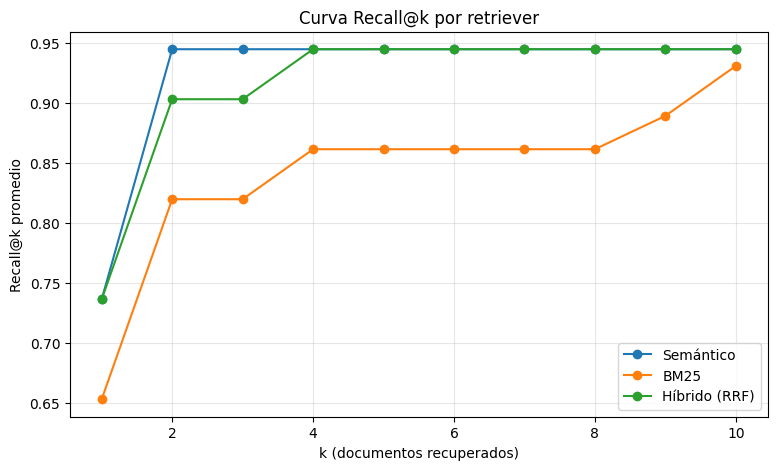

💡 Lectura de la curva:
   - ¿A partir de qué k el recall se aplana? Ese es un buen candidato para el RAG.
   - Recuerda el costo de k grande: tokens, latencia y 'lost in the middle'.



In [ ]:
ks = range(1, 11)
plt.figure(figsize=(9, 5))

for name, fn in retrievers.items():
    recalls = []
    for k in ks:
        vals = [recall_at_k(fn(g["query"], k=len(doc_ids)), g["relevant"], k)
                for g in golden_retrieval]
        recalls.append(np.mean(vals))
    plt.plot(list(ks), recalls, marker="o", label=name)

plt.xlabel("k (documentos recuperados)")
plt.ylabel("Recall@k promedio")
plt.title("Curva Recall@k por retriever")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("""💡 Lectura de la curva:
   - ¿A partir de qué k el recall se aplana? Ese es un buen candidato para el RAG.
   - Recuerda el costo de k grande: tokens, latencia y 'lost in the middle'.
""")

## 6.3 Autopsia de fallos (*error analysis*)

Los promedios dicen *cuánto* falla; mirar casos concretos dice *por qué*.
Busquemos las queries donde algún retriever fracasó por completo (MRR = 0
o el primer relevante quedó muy abajo):

In [ ]:
print("🔍 Queries problemáticas (MRR < 0.5 en algún retriever):\n")
for i, item in enumerate(golden_retrieval):
    rrs = {name: all_results[name][i]["MRR"] for name in retrievers}
    if min(rrs.values()) < 0.5:
        print(f"[{item['type']}] '{item['query']}'")
        print(f"   relevantes: {sorted(item['relevant'])}")
        for name, fn in retrievers.items():
            top3 = fn(item["query"], k=3)
            marks = ["✅" if d in item["relevant"] else "❌" for d in top3]
            print(f"   {name:<15} MRR={rrs[name]:.2f}  top-3: " +
                  ", ".join(f"{m}{d}" for m, d in zip(marks, top3)))
        print()

🔍 Queries problemáticas (MRR < 0.5 en algún retriever):

[parafrasis] 'the model makes up things that are not true'
   relevantes: ['llm_02', 'rag_02']
   Semántico       MRR=1.00  top-3: ✅llm_02, ✅rag_02, ❌llm_01
   BM25            MRR=0.25  top-3: ❌bm_03, ❌lg_03, ❌emb_01
   Híbrido (RRF)   MRR=1.00  top-3: ✅rag_02, ✅llm_02, ❌emb_02



**Patrones típicos que revela este análisis** (verifica cuáles aparecen aquí):
- BM25 falla en paráfrasis → *ningún* término coincide → score 0 para los relevantes
- El semántico confunde documentos del **mismo tema** (todos los `vdb_*` son "parecidos")
- El híbrido hereda los errores cuando **ambos** componentes fallan a la vez
- Queries con un solo relevante son de "alto riesgo": no hay red de seguridad

---
# PARTE 7: Lo que NO medimos hoy (y dónde entra en el curso)

1. **Calidad del chunking**: el mismo corpus con chunks de 100 vs 500 tokens da
   retrievers distintos. Se evalúa re-corriendo estas mismas métricas con cada
   estrategia de chunking (→ ejercicio 4).
2. **El modelo de embeddings**: `all-MiniLM-L6-v2` vs modelos más grandes — mismo
   protocolo: mismas queries, mismos qrels, comparar tablas (benchmark de referencia: MTEB).
3. **Relevancia graduada**: hoy usamos binaria; nDCG brilla con escalas 0-3.
4. **La generación**: un retrieval perfecto no garantiza una buena respuesta —
   eso es la **Clase 3** (RAGAS: faithfulness, answer relevancy, context precision/recall).

> 🔮 **Conexión con observabilidad (Bloque 2)**: estas métricas requieren qrels...
> pero en producción nadie te da qrels. Ahí se usan *señales indirectas*: ¿el LLM citó
> el documento? ¿el usuario reformuló la query? Lo veremos en monitoreo online.


---
# Ejercicios Propuestos

1. **A mano**: para el ranking `[✅, ❌, ❌, ✅, ❌]` con 2 relevantes en total, calcula
   a mano P@3, R@3, RR, AP y nDCG@5. Verifica después con las funciones.

2. **Sensibilidad de RRF**: repite el experimento de la Parte 6 con
   $k_{rrf} \in \{1, 10, 60, 1000\}$. ¿Cómo cambia el ranking híbrido? ¿Por qué
   $k_{rrf}=1$ vuelve al híbrido casi "ganador se lleva todo"?

3. **Rompe al híbrido**: diseña 3 queries nuevas donde el híbrido pierda contra el
   mejor individual. Pista: queries donde un retriever acierta y el otro mete mucho
   ruido correlacionado.

4. **Chunking**: parte cada pasaje del corpus en oraciones individuales (nuevo corpus,
   ~40 "chunks") y re-ejecuta la evaluación. Ojo: tendrás que rehacer los qrels.
   ¿Mejora o empeora el nDCG? ¿Por qué?

5. **Métrica de producto**: tu RAG solo pasa los top-3 chunks al LLM y basta un chunk
   correcto para responder. ¿Qué métrica de esta clase describe mejor la experiencia
   del usuario? Justifica.

6. **Qrels incompletos**: elimina un documento relevante de los qrels de una query
   (simulando un juicio olvidado) y observa cómo cambian recall y MAP. ¿En qué dirección
   sesgan los qrels incompletos?


---
# Conclusión

### Las métricas de retrieval de un vistazo

| Métrica | Pregunta que responde | ¿Usa orden? | Ideal para |
|---------|----------------------|-------------|------------|
| **Precision@k** | ¿Cuánto ruido hay en el contexto? | ❌ | Presupuesto de tokens |
| **Recall@k** | ¿Cuánta información perdí? | ❌ | Elegir k |
| **Hit Rate@k** | ¿Entró al menos un relevante? | ❌ | QA con 1 chunk suficiente |
| **MRR** | ¿Qué tan arriba está el 1er relevante? | ✅ | QA factual |
| **MAP** | ¿Todos los relevantes están arriba? | ✅ | Comparar retrievers |
| **nDCG@k** | ¿Ganancia descontada vs ranking ideal? | ✅ | Relevancia graduada, el estándar |

### Ideas clave
1. **Evalúa por componentes**: el retrieval tiene sus propias métricas, previas al LLM
2. **El orden importa**: dos retrievers con el mismo Recall@5 pueden dar experiencias
   opuestas — por eso existen MRR, MAP y nDCG
3. **$k$ es una decisión de producto**: la curva Recall@k la informa
4. **Analiza por tipo de query y haz autopsias**: los promedios esconden los porqués
5. Ningún retriever gana en todo — el híbrido compra **robustez**, no supremacía
